In [250]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

print("Libraries imported successfully!")

Libraries imported successfully!


# 1. Data Loading & Initial Inspection
Let's load our dataset and understand its shape, data types, and basic statistics.

In [15]:
df=pd.read_csv("/kaggle/input/datasets/luisfernandolfss/bank-transactions-data-2/bank_transactions_data_2.csv")

In [16]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [17]:
df.shape
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


# Exploratory Data Analysis

## Transaction

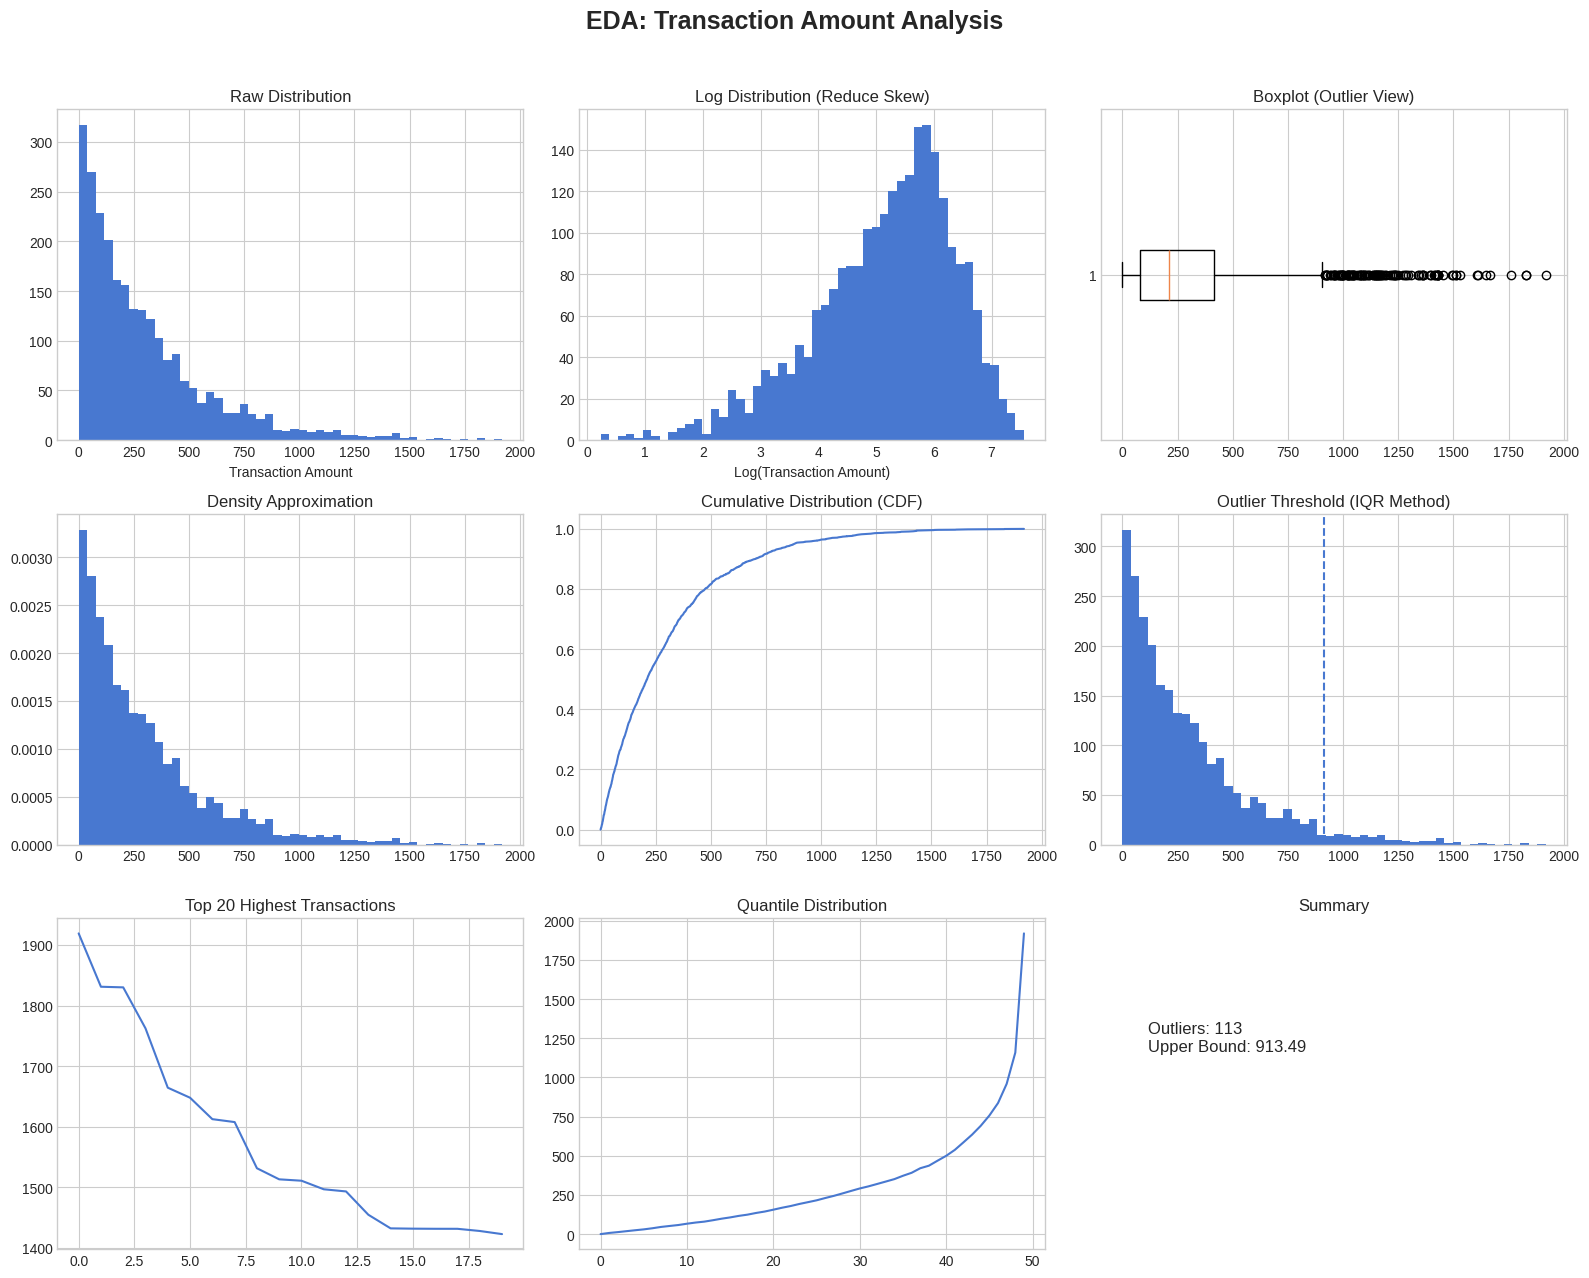

In [18]:
q1 = df['TransactionAmount'].quantile(0.25)
q3 = df['TransactionAmount'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = df[df['TransactionAmount'] > upper_bound]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle(
    "EDA: Transaction Amount Analysis",
    fontsize=18,
    fontweight='bold'
)


axes[0,0].hist(df['TransactionAmount'], bins=50)
axes[0,0].set_title("Raw Distribution")
axes[0,0].set_xlabel("Transaction Amount")
axes[0,1].hist(np.log1p(df['TransactionAmount']), bins=50)
axes[0,1].set_title("Log Distribution (Reduce Skew)")
axes[0,1].set_xlabel("Log(Transaction Amount)")
axes[0,2].boxplot(df['TransactionAmount'], vert=False)
axes[0,2].set_title("Boxplot (Outlier View)")
axes[1,0].hist(df['TransactionAmount'], bins=50, density=True)
axes[1,0].set_title("Density Approximation")
sorted_vals = np.sort(df['TransactionAmount'])
cdf = np.arange(len(sorted_vals)) / len(sorted_vals)
axes[1,1].plot(sorted_vals, cdf)
axes[1,1].set_title("Cumulative Distribution (CDF)")
axes[1,2].hist(df['TransactionAmount'], bins=50)
axes[1,2].axvline(upper_bound, linestyle='--')
axes[1,2].set_title("Outlier Threshold (IQR Method)")
top_vals = df['TransactionAmount'].sort_values(ascending=False).head(20)
axes[2,0].plot(top_vals.values)
axes[2,0].set_title("Top 20 Highest Transactions")
quantiles = df['TransactionAmount'].quantile(np.linspace(0,1,50))
axes[2,1].plot(quantiles.values)
axes[2,1].set_title("Quantile Distribution")
axes[2,2].text(
    0.1, 0.6,
    f"Outliers: {len(outliers)}\nUpper Bound: {upper_bound:.2f}",
    fontsize=12
)
axes[2,2].set_title("Summary")
axes[2,2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Analysis

**Transaction Amount Analysis**

**1. Objective**
The purpose of this analysis is to examine the distribution of transaction amounts and identify patterns that may indicate abnormal or potentially fraudulent behavior.

The dataset consists of 2,512 transactions, with a primary focus on the `TransactionAmount` variable.

---

**2. Distribution Analysis**

The transaction amount distribution is highly right-skewed:

* Most transactions fall within low to medium ranges
* A long tail extends toward higher values (up to approximately 1900)

Insight : 
A relatively small number of transactions account for disproportionately large values compared to the rest of the dataset.

After applying a logarithmic transformation:

* The distribution becomes more symmetric and closer to normal
* The skewness is largely driven by extreme high-value transactions

Insight :
The dataset shows high variance, primarily influenced by a small number of large transactions.

---

**3. Outlier Analysis**

Using the IQR method:

* Upper bound: approximately 913
* Number of outliers: 113 transactions (~4.5%)

Insight :
A non-trivial portion of transactions lies outside the expected range, suggesting potential anomalies.

For extreme values:

* Top transactions range from 1400 to 1900
* These values are significantly higher than the median (approximately 211)

Insight :
The outliers are not marginal; they exist on a completely different scale and are therefore important for risk analysis.

---

**4. Distribution Behavior**

From the cumulative distribution:

* Around 80% of transactions are below approximately 500
* Most activity is concentrated in lower-value transactions

Insight :
High-value transactions are rare but potentially high-impact, especially in fraud-related scenarios.

From quantile analysis:

* There is a sharp increase in the upper quantiles (top 10–5%)
* This indicates a heavy-tailed distribution

Insight :
Risk exposure is likely concentrated in a small fraction of extreme transactions.

---

**5. Risk Interpretation**

From a fraud risk perspective:

* High-value transactions are not necessarily fraudulent, but they are:

  * Less frequent
  * Higher impact if fraudulent

* Potential patterns to investigate further include:

  * Transaction amount relative to account balance
  * Rapid transaction activity within short time intervals
  * Behavioral inconsistencies (e.g., login patterns, device changes)

Key point :
Fraud risk is not determined by transaction size alone, but by how that transaction compares to expected behavior.

---

**6. Key Takeaways**

* The distribution is non-normal and heavily right-skewed
* Approximately 4.5% of transactions are statistical outliers
* Around 80% of transactions are below ~500
* Risk is likely concentrated in the upper tail of the distribution

---
**Analyst Note**

High transaction amounts alone are not reliable indicators of fraud. More effective detection comes from combining transaction size with behavioral context and deviation from normal patterns.


In [19]:
df['amount_balance_ratio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1)

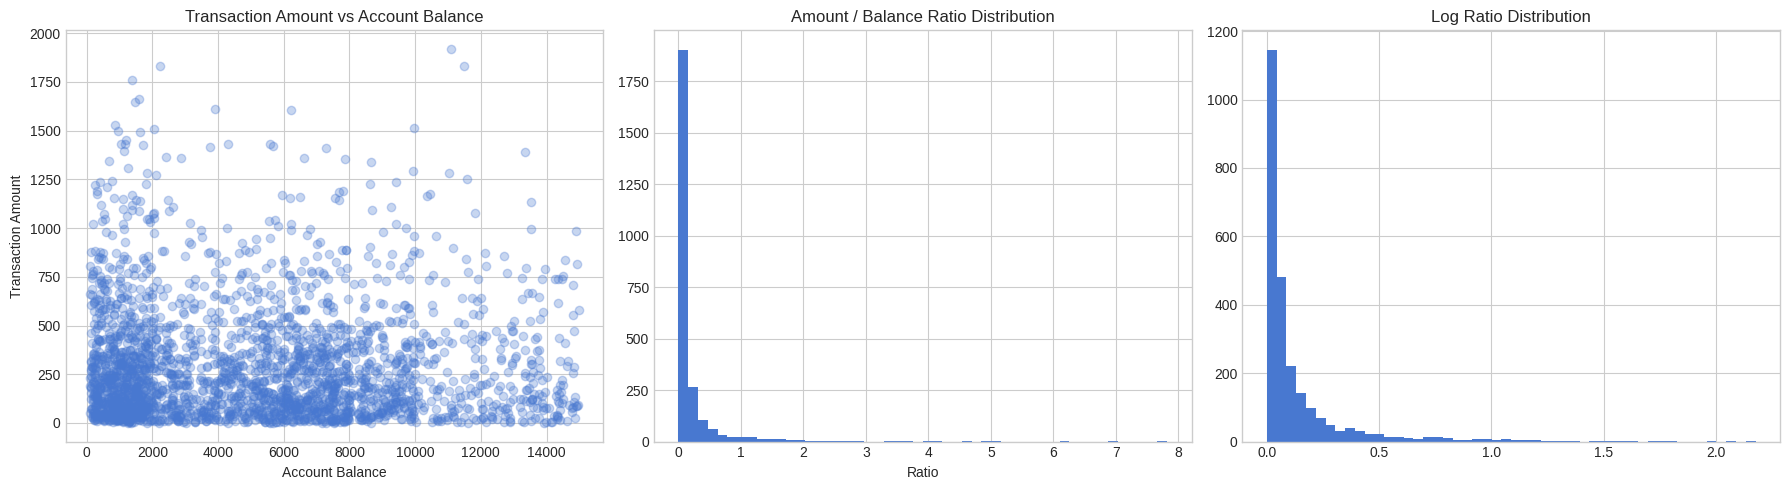

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(
    df['AccountBalance'],
    df['TransactionAmount'],
    alpha=0.3
)
axes[0].set_title("Transaction Amount vs Account Balance")
axes[0].set_xlabel("Account Balance")
axes[0].set_ylabel("Transaction Amount")
axes[1].hist(df['amount_balance_ratio'], bins=50)
axes[1].set_title("Amount / Balance Ratio Distribution")
axes[1].set_xlabel("Ratio")
axes[2].hist(np.log1p(df['amount_balance_ratio']), bins=50)
axes[2].set_title("Log Ratio Distribution")

plt.tight_layout()
plt.show()

In [21]:
suspicious = df[df['amount_balance_ratio'] > 0.5]

print("Suspicious transactions:", len(suspicious))
len(suspicious)/len(df)

Suspicious transactions: 227


0.09036624203821655

In [22]:
suspicious.sort_values(
    by='amount_balance_ratio',
    ascending=False
).head(10)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,amount_balance_ratio
2273,TX002274,AC00357,806.97,2023-03-07 17:48:05,Debit,Seattle,D000691,193.221.15.59,M028,Online,25,Student,11,1,102.20,2024-11-04 08:08:53,7.819477
2191,TX002192,AC00131,879.25,2023-11-07 17:44:12,Credit,Memphis,D000073,190.164.160.79,M086,Online,24,Student,137,1,125.85,2024-11-04 08:08:02,6.931415
1459,TX001460,AC00460,659.71,2023-05-05 16:10:24,Credit,San Jose,D000095,150.83.4.238,M052,Branch,21,Student,148,1,106.86,2024-11-04 08:09:32,6.116355
1258,TX001259,AC00020,603.23,2023-08-24 17:34:13,Debit,Detroit,D000238,38.210.156.148,M017,Branch,28,Student,48,1,117.98,2024-11-04 08:08:18,5.070012
2382,TX002383,AC00119,761.73,2023-09-11 17:15:04,Debit,Columbus,D000191,89.6.100.149,M075,ATM,19,Student,27,1,151.28,2024-11-04 08:09:23,5.002167
311,TX000312,AC00285,1221.65,2023-09-27 16:55:35,Debit,Denver,D000098,83.207.115.164,M091,Online,27,Student,153,1,243.92,2024-11-04 08:10:41,4.987955
934,TX000935,AC00456,1022.75,2023-01-19 16:45:16,Credit,San Jose,D000294,190.164.160.79,M091,Branch,62,Doctor,158,1,207.74,2024-11-04 08:10:47,4.899636
450,TX000451,AC00495,745.03,2023-08-03 17:42:02,Debit,Fort Worth,D000031,30.92.249.132,M075,Online,28,Student,231,1,160.57,2024-11-04 08:09:15,4.611190
13,TX000014,AC00264,781.76,2023-11-20 16:39:15,Debit,Memphis,D000054,193.83.0.183,M025,ATM,26,Student,123,1,189.69,2024-11-04 08:07:06,4.099638
449,TX000450,AC00407,689.29,2023-01-06 17:30:07,Debit,El Paso,D000286,166.41.54.117,M034,ATM,22,Student,100,1,168.84,2024-11-04 08:07:49,4.058467


### Transaction Amount vs Account Balance

**Objective**
The goal of this analysis is to identify transactions that are disproportionate relative to account balance, which may indicate abnormal or potentially fraudulent behavior.

To capture this, a derived feature is introduced:

Amount-to-Balance Ratio = TransactionAmount / AccountBalance

---

**Scatter Analysis: Amount vs Balance**

The scatter plot illustrates the relationship between transaction amount and account balance.

Observations:

* Most transactions are concentrated in the low amount range, regardless of account balance
* There is no strong linear relationship between balance and transaction amount
* Some transactions show relatively high amounts despite low balances

Insight : 
Transaction size does not strongly depend on balance, indicating that absolute amount alone is not a reliable risk indicator.

---

**Ratio Distribution Analysis**

Raw ratio distribution:

* Highly right-skewed
* Most transactions have a low ratio (below 0.2)
* A long tail extends beyond 1.0, reaching up to around 8.0

Insight :
Most users transact conservatively relative to their balance, while a small portion exhibits more aggressive or unusual behavior.

Log-transformed ratio:

* The distribution becomes more balanced
* Differences between moderate and extreme behavior become clearer

Insight :
Extreme ratios highlight inconsistency in user behavior and potential deviations from normal patterns.

---

**Suspicious Transaction Identification**

A simple heuristic is applied:

Transactions where the amount is at least 50% of the account balance.

Results:

* Suspicious transactions: 227
* Proportion: approximately 9% of total transactions

Insight :
A meaningful share of transactions involves users spending a large portion of their balance. This may indicate:

* Urgent or unusual behavior
* Possible account takeover
* Elevated financial risk

---

**Risk Interpretation**

From a fraud risk perspective:

* A high transaction amount alone is not necessarily risky
* A high transaction relative to balance is a stronger signal

Key risk patterns include:

* Low balance combined with high transaction value
* Ratios approaching or exceeding 1.0
* Extreme outliers with ratios above 2–5

Key idea :
Fraud risk is better understood through relative behavior rather than absolute transaction size.

---

**Key Takeaways**

* Transaction amount is not strongly correlated with account balance
* The ratio distribution is heavily right-skewed, indicating diverse user behavior
* Approximately 9% of transactions exceed 50% of account balance
* High-ratio transactions represent a segment that warrants further investigation


## Time Analysis

In [23]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

df['hour'] = df['TransactionDate'].dt.hour

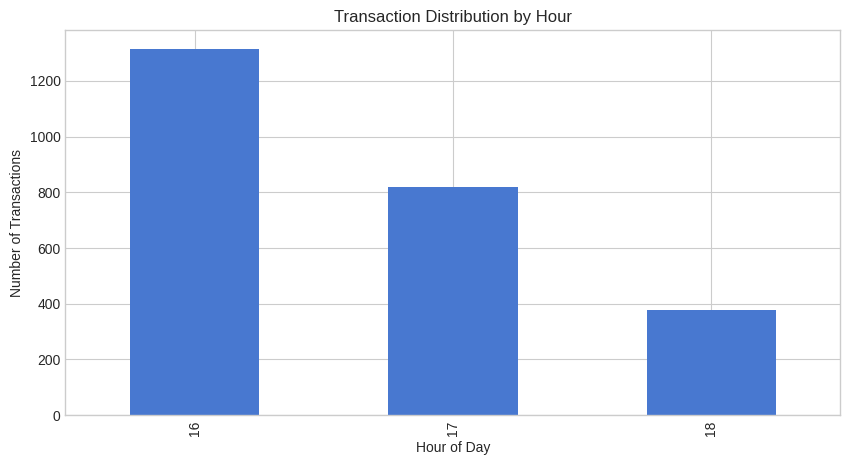

In [24]:
plt.figure(figsize=(10,5))
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Transaction Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()

In [28]:
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 else 0)
df['high_ratio'] = (df['amount_balance_ratio'] > 0.5).astype(int)


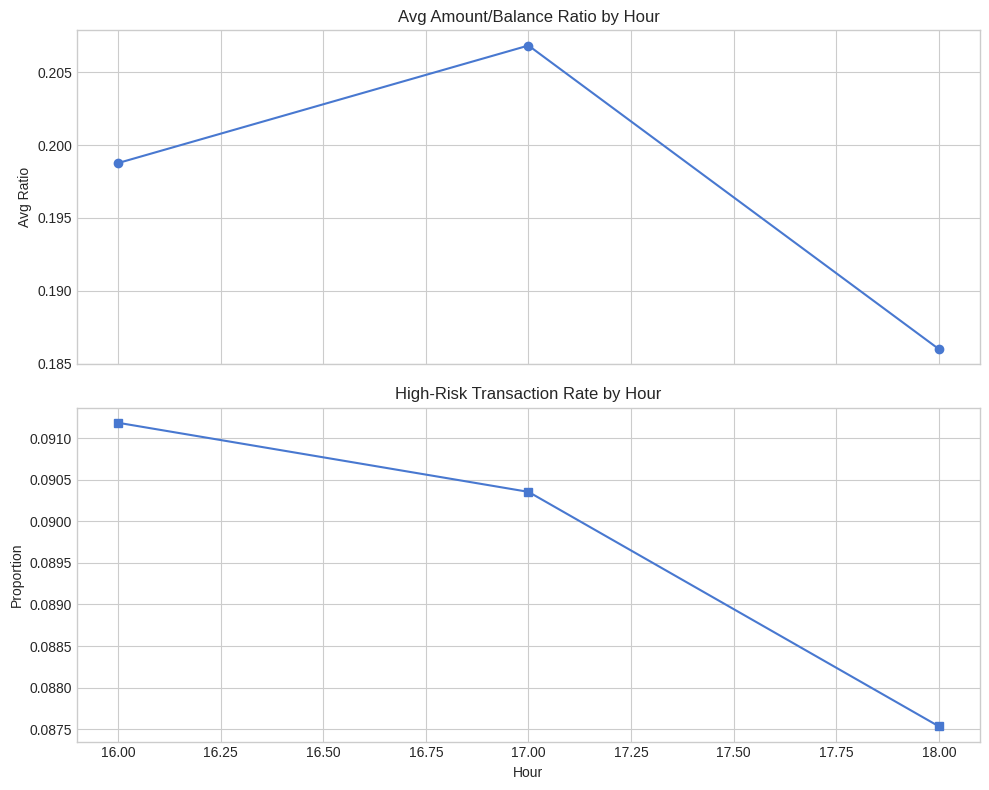

In [30]:
hourly = df.groupby('hour').agg({
    'amount_balance_ratio': 'mean',
    'high_ratio': 'mean'
})

fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)
axes[0].plot(hourly.index, hourly['amount_balance_ratio'], marker='o')
axes[0].set_title("Avg Amount/Balance Ratio by Hour")
axes[0].set_ylabel("Avg Ratio")
axes[1].plot(hourly.index, hourly['high_ratio'], marker='s')
axes[1].set_title("High-Risk Transaction Rate by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

### **Time Context Analysis**

**Objective**
This analysis examines whether transaction behavior and associated risk vary across different hours of the day.

---

**Data Limitation**

The dataset is concentrated within a narrow time window, specifically between 16:00 and 18:00.

This limits the ability to perform a comprehensive time-of-day analysis, as the data does not cover a full daily cycle.

---

**Transaction Distribution**

* The highest transaction volume occurs around 16:00
* Activity gradually declines toward 18:00

Insight : 
Transactions are clustered within a specific operational period rather than being distributed evenly throughout the day.

---

**Risk Analysis by Hour**

Average amount-to-balance ratio:

* Remains relatively stable across hours (approximately 0.19–0.20)

High-risk transaction rate:

* Also consistent across hours (around 9%)

Insight :
There is no meaningful variation in risk across the observed time window.

---

**Interpretation**

* Time of day does not appear to be a strong differentiator of risk in this dataset
* Behavioral and financial features, such as transaction ratios or user activity patterns, are likely to provide more useful signals

---

**Analyst Note**

Time-based features are often valuable in fraud detection, especially for identifying unusual activity patterns (e.g., late-night transactions). However, their effectiveness depends on having sufficient temporal coverage.

In this case, the limited time range reduces the usefulness of time as a predictive feature.


## Behavioral and Contextual Feature

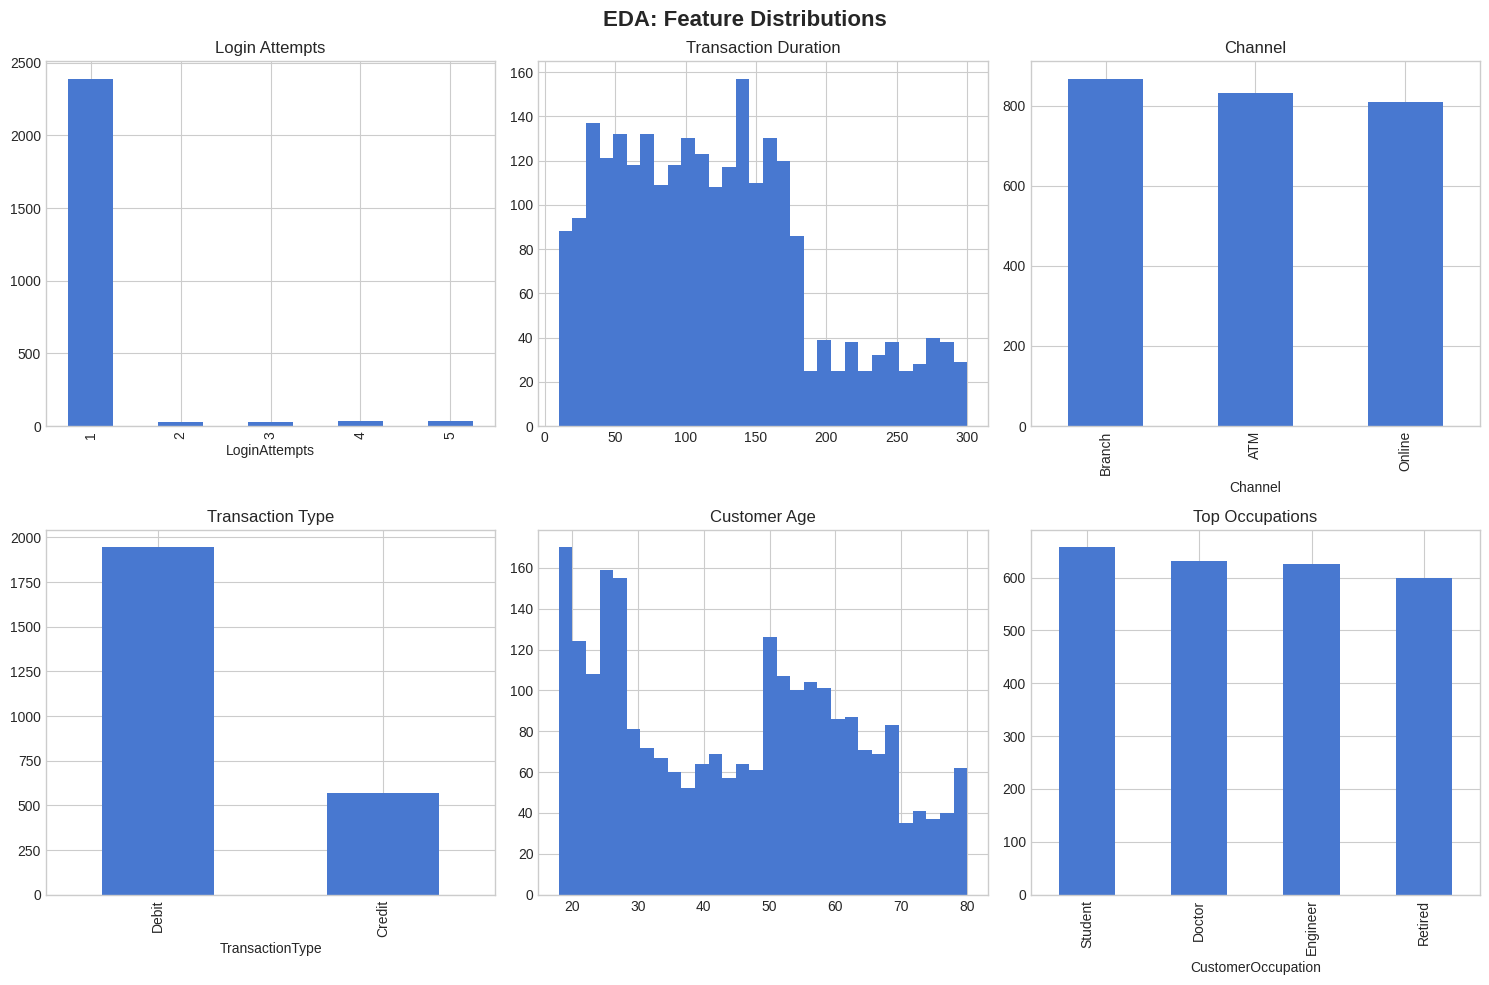

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
df['LoginAttempts'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Login Attempts")
axes[0,1].hist(df['TransactionDuration'], bins=30)
axes[0,1].set_title("Transaction Duration")
df['Channel'].value_counts().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title("Channel")
df['TransactionType'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Transaction Type")
axes[1,1].hist(df['CustomerAge'], bins=30)
axes[1,1].set_title("Customer Age")
df['CustomerOccupation'].value_counts().head(10).plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title("Top Occupations")

plt.suptitle("EDA: Feature Distributions", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

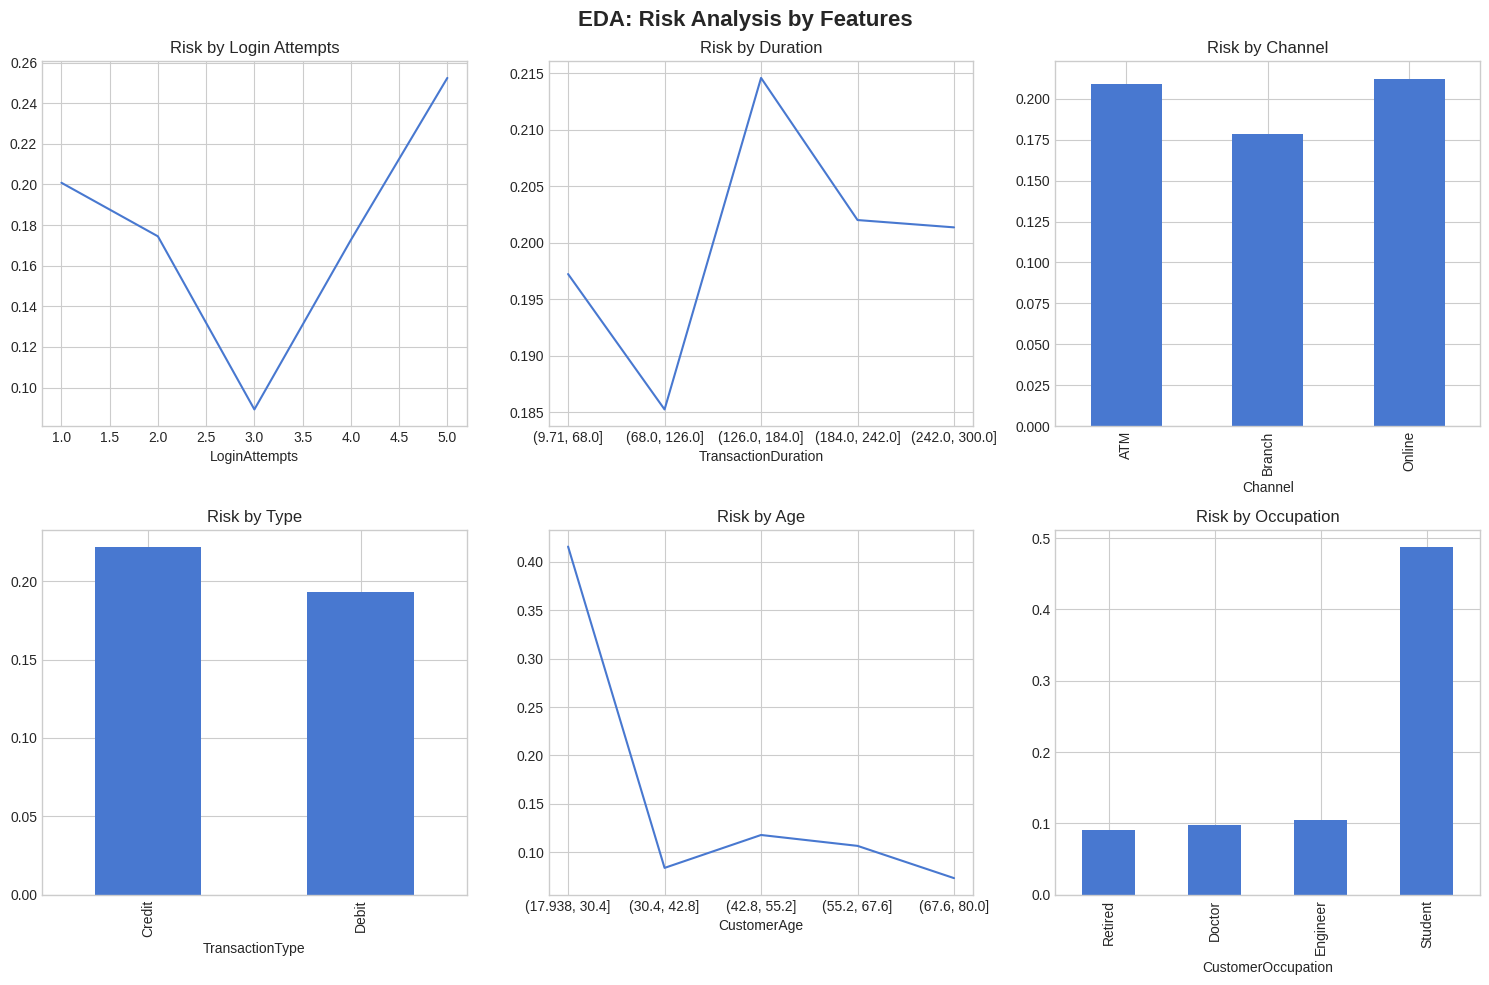

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
df.groupby('LoginAttempts')['amount_balance_ratio'].mean().plot(ax=axes[0,0])
axes[0,0].set_title("Risk by Login Attempts")
df.groupby(pd.cut(df['TransactionDuration'], bins=5))['amount_balance_ratio'].mean().plot(ax=axes[0,1])
axes[0,1].set_title("Risk by Duration")
df.groupby('Channel')['amount_balance_ratio'].mean().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title("Risk by Channel")
df.groupby('TransactionType')['amount_balance_ratio'].mean().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Risk by Type")
df.groupby(pd.cut(df['CustomerAge'], bins=5))['amount_balance_ratio'].mean().plot(ax=axes[1,1])
axes[1,1].set_title("Risk by Age")
top_occ = df['CustomerOccupation'].value_counts().head(10).index
df[df['CustomerOccupation'].isin(top_occ)] \
  .groupby('CustomerOccupation')['amount_balance_ratio'].mean() \
  .sort_values() \
  .plot(kind='bar', ax=axes[1,2])

axes[1,2].set_title("Risk by Occupation")

plt.suptitle("EDA: Risk Analysis by Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Behavioral and Contextual Feature Analysis**

**Objective**
This analysis examines additional behavioral and contextual features to identify patterns associated with elevated transaction risk.

Risk is evaluated using the amount-to-balance ratio.

---

**Feature Distributions**

Login attempts

* Most transactions involve a single login attempt
* Only a small number of cases show multiple attempts (2–5)

Insight :
The dataset is highly imbalanced, with the majority of users exhibiting normal login behavior.

Transaction duration

* Values are spread widely (approximately 10–300 seconds)
* No clear concentration in a specific range

Insight :
Transaction duration varies significantly and may require transformation or binning to be more informative.

Channel

* Transactions are distributed across branch, ATM, and online channels

Insight :
All channels are sufficiently represented, allowing meaningful comparison.

Transaction type

* Most transactions are debit
* Credit transactions are less frequent

Customer age

* Distributed across a wide range (18–80)
* No strong skew observed

Occupation

* Several occupations dominate (e.g., student)
* Distribution is relatively balanced among the main categories

---

**Risk Analysis by Feature**

Login attempts vs risk

* Higher login attempts are associated with higher risk
* However, these cases are rare

Insight :
The observed pattern may be driven by small sample sizes and should be interpreted cautiously.

Transaction duration vs risk

* No clear monotonic relationship
* Slightly higher risk appears in mid-range durations

Insight :
Transaction duration alone is not a strong predictor of risk.

Channel vs risk

* Online transactions show slightly higher risk
* Branch transactions show lower risk

Insight :
Digital channels may carry higher exposure compared to physical channels.

Transaction type vs risk

* Credit transactions show marginally higher risk than debit

Insight :
The difference exists but is not substantial.

Customer age vs risk

* Younger groups appear to have higher risk
* Variability across groups is high
 
Insight :
This pattern may be influenced by imbalance or small group sizes.

Occupation vs risk

* Some occupations show higher risk levels
* There is notable variation across categories

Insight :
Differences are likely affected by limited sample sizes and should not be overgeneralized.

---

**Key Takeaways**

Reliable signals:

* Amount-to-balance ratio
* Channel (especially online vs branch)

Weak or noisy signals:

* Transaction duration
* Transaction type

Potentially misleading signals (require caution):

* Login attempts
* Age
* Occupation

---

**Interpretation**

This analysis highlights an important point: not all visible differences translate into reliable risk indicators.

Several features show variation, but these patterns may be driven by:

* Data imbalance
* Small sample sizes
* Lack of consistency across groups

---

**Analyst Note**

Effective fraud detection depends on consistent and robust signals rather than superficial patterns.

In this dataset, financial behavior (relative transaction size) and channel context appear to be more reliable indicators than demographic or sparse behavioral features.


In [33]:
age_bins = pd.cut(df['CustomerAge'], bins=5)

age_analysis = df.groupby(age_bins)['amount_balance_ratio'].agg([
    'count',
    'mean',
    'median',
    'max',
    'std'
])

age_analysis

,count,mean,median,max,std
CustomerAge,,,,,
"(17.938, 30.4]",797,0.415834,0.145347,7.819477,0.770610
"(30.4, 42.8]",384,0.083689,0.032037,2.038590,0.202282
"(42.8, 55.2]",515,0.117706,0.038069,3.622779,0.308641
"(55.2, 67.6]",518,0.106454,0.038174,4.899636,0.324907
"(67.6, 80.0]",298,0.073104,0.039091,0.921514,0.112858


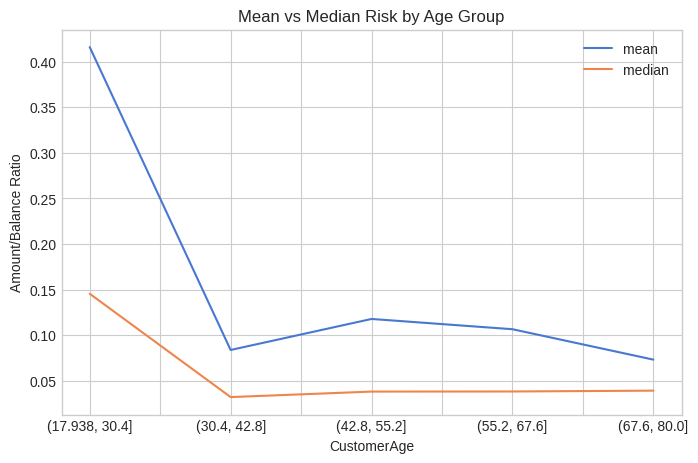

In [34]:
age_analysis[['mean','median']].plot(figsize=(8,5))
plt.title("Mean vs Median Risk by Age Group")
plt.ylabel("Amount/Balance Ratio")
plt.show()

In [35]:
df.groupby(age_bins)['amount_balance_ratio'].quantile([0.5, 0.75, 0.9]).unstack()

,0.50,0.75,0.90
CustomerAge,,,
"(17.938, 30.4]",0.145347,0.437820,1.120637
"(30.4, 42.8]",0.032037,0.070330,0.171659
"(42.8, 55.2]",0.038069,0.088323,0.221870
"(55.2, 67.6]",0.038174,0.089488,0.195022
"(67.6, 80.0]",0.039091,0.079895,0.159924


### **Customer Age vs Risk**

**Objective**
This analysis examines whether customer age is associated with transaction risk, measured using the amount-to-balance ratio.

---

**Initial Observation (Mean-Based)**

Initial results suggested that younger users exhibit higher average risk.

However, mean-based metrics can be misleading in heavy-tailed distributions, as they are sensitive to extreme values and outliers.

---

**Robust Analysis (Quantile-Based)**

To validate the pattern, the distribution is analyzed using multiple quantiles:

| Age Group | Median (50%) | 75th Percentile | 90th Percentile |
|----------|-------------|----------------|----------------|
| 18–30    | 0.145       | 0.438          | 1.121          |
| 30–42    | 0.032       | 0.070          | 0.172          |
| 42–55    | 0.038       | 0.088          | 0.222          |
| 55–67    | 0.038       | 0.089          | 0.195          |
| 67–80    | 0.039       | 0.080          | 0.160          |

---

**Key Findings**

* The youngest age group (18–30) shows:

  * A significantly higher median risk compared to other groups
  * Much higher upper quantiles
  * Extreme values exceeding 1.0 (transactions equal to or greater than balance)

* Other age groups remain relatively stable across all quantiles

---

**Interpretation**

Core insight:
Younger users consistently exhibit higher transaction-to-balance ratios across the entire distribution, not just in extreme cases.

This suggests:

* A structural behavioral difference rather than isolated outliers
* A higher tendency to transact aggressively relative to available balance

---

**Important Nuance**

This does not imply that younger users are fraudulent.

Instead, it indicates that they represent a segment with higher financial risk exposure.

---
```


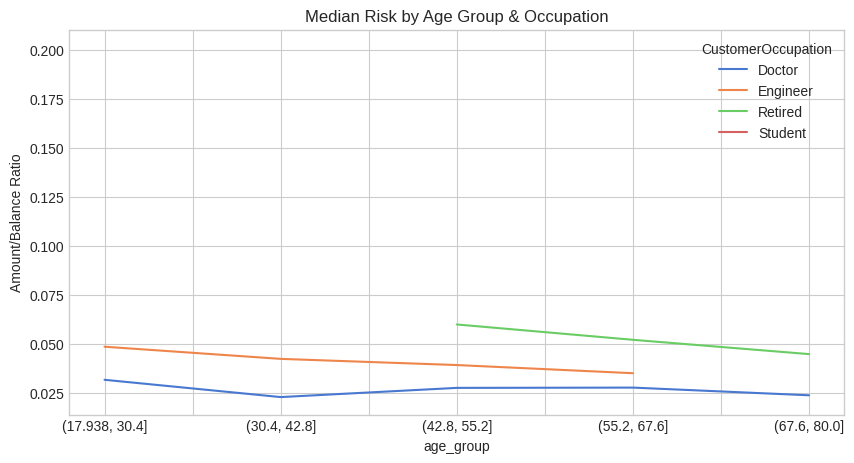

In [36]:
df['age_group'] = pd.cut(df['CustomerAge'], bins=5)

df.groupby(['age_group','CustomerOccupation'])['amount_balance_ratio'] \
  .median() \
  .unstack() \
  .plot(figsize=(10,5))

plt.title("Median Risk by Age Group & Occupation")
plt.ylabel("Amount/Balance Ratio")
plt.show()

In [42]:
print(df[df.CustomerOccupation=='Student']['CustomerAge'].min())
      
df[df.CustomerOccupation=='Student']['CustomerAge'].max()

18


28

### **EDA: Age vs Occupation Interaction**

**Objective**
This analysis examines whether customer occupation, particularly the student category, independently contributes to transaction risk, or whether the observed effect is driven by age.

Risk is measured using the median amount-to-balance ratio to ensure robustness against outliers.

---

**Approach**

* Customers are grouped into age bins
* Risk is evaluated using the median ratio within each group
* Comparisons are made across occupation categories within each age segment

---

**Key Observation**

* The student category appears only within the youngest age group (18–30)
* There are no student observations in older age groups

Implication
This prevents a direct comparison of student behavior across different age segments.

---

**Results**

* The youngest age group (18–30) exhibits higher median risk
* Other occupations (e.g., doctor, engineer, retired) show relatively stable and lower risk across age groups
* There is no consistent pattern of elevated risk across occupations

---

**Interpretation**

Core insight:
The higher risk observed among students is confounded by age, since student observations are concentrated entirely within the youngest age group.

This indicates that:

* The apparent “student risk” is not an independent occupation effect
* The observed pattern is primarily driven by age-related behavior

---

**Key Takeaways**

* Age is the primary driver of risk in this context
* Occupation (specifically student) does not provide independent predictive value
* The observed occupation effect is a result of data structure and confounding

---

**Analyst Note**

This analysis highlights the importance of identifying confounding variables in exploratory analysis.

Apparent relationships between features do not necessarily reflect true behavioral or causal effects, particularly when one variable is structurally tied to another.

In this case:

* Age explains the variation in risk
* Occupation does not add meaningful independent signal

---

**Modeling Implication**

* Prioritize age-based features, such as CustomerAge or derived indicators like `is_young`



# Feature Engineering

In [140]:
df['amount_balance_ratio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1)
df['is_young'] = (df['CustomerAge'] < 30).astype(int)
df['is_online'] = (df['Channel'] == 'Online').astype(int)
df['is_atm'] = (df['Channel'] == 'ATM').astype(int)
df['high_login'] = (df['LoginAttempts'] > 1).astype(int)
df['fast_txn'] = (df['TransactionDuration'] < 60).astype(int)

features = [
    'TransactionAmount',
    'AccountBalance',
    'amount_balance_ratio',
    'is_young',
    'is_online',
    'is_atm',
    'high_login',
    'fast_txn',
    
]

In [141]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['Hour'] = df['TransactionDate'].dt.hour
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek   # Monday = 0
df['IsWeekend'] = df['DayOfWeek'] >= 5                  # Saturday/Sunday = 1

df['Day'] = df['TransactionDate'].dt.day
df['Month'] = df['TransactionDate'].dt.month

### **Feature Engineering: Core Behavioral, Contextual, and Temporal Features**

**Objective**
The goal of this feature set is to capture key financial, behavioral, contextual, and temporal signals relevant for identifying abnormal or high-risk transactions, while keeping the feature space interpretable and efficient.

---

**Financial Features (Primary Signal)**

* Transaction amount and account balance are retained
* Amount-to-balance ratio measures transaction size relative to available funds

Insight :
The ratio is a stronger signal than absolute values, as it reflects behavioral intensity.

Implication
Models should prioritize relative financial behavior over raw magnitude.

---

**Age-Based Feature (Behavioral Segmentation)**

* `is_young` identifies users under 30

Insight :
Younger users tend to exhibit higher transaction-to-balance ratios.

Implication
Age should be used for segmentation, not as a direct proxy for risk.

---

**Channel Features (Contextual Information)**

* `is_online` and `is_atm` encode transaction channels
* Branch acts as baseline

Insight :
Online transactions show slightly higher exposure to risk.

Implication
Channel adds useful environmental context, especially for digital behavior.

---

**Login Behavior (Simplified Signal)**

* `high_login` flags multiple login attempts
 
Insight :
Repeated login attempts may indicate abnormal access patterns.

Implication
Binary encoding reduces noise while preserving key signals.

---

**Transaction Speed (Behavioral Signal)**

* `fast_txn` captures transactions completed in under 60 seconds

Insight :
Fast transactions may indicate impulsive or automated behavior.

Implication
This is a weak signal and should be treated as supportive, not primary.

---

**Temporal Features (Contextual Timing)**

* `Hour`: hour of transaction
* `DayOfWeek`: day index (0 = Monday)
* `IsWeekend`: weekend indicator
* `Day`, `Month`: calendar components

Insight :
Time-based features provide contextual information about when transactions occur, which can be useful in detecting unusual timing patterns.

Implication
In this dataset, temporal coverage is limited (transactions concentrated in a narrow window), so these features are unlikely to be strong standalone predictors but may still add marginal value in combination with other signals.

---

**Feature Summary**

The final feature set includes:

* Financial signals (amount, balance, ratio)
* Behavioral indicators (login activity, transaction speed)
* Contextual variables (age, channel)
* Temporal features (hour, weekday, calendar attributes)

---

**Key Takeaways**

* Relative financial behavior remains the strongest signal
* Contextual features (channel, age) add moderate value
* Temporal features provide limited signal due to dataset constraints
* Simpler, well-justified features are more reliable than overly complex ones

---

**Modeling Implication**

This feature set is designed to support:

* Clustering for behavioral segmentation
* Anomaly detection for identifying unusual patterns
* Risk scoring through a combination of complementary signals

Temporal features should be treated as auxiliary inputs, with primary emphasis placed on financial and behavioral patterns.


# Clustering

In [142]:
X = pd.concat([
   df[[
    'TransactionAmount',
    'AccountBalance',
    'amount_balance_ratio',
    'is_young',
       'Hour', 'DayOfWeek',
    'TransactionDuration', 'LoginAttempts','CustomerAge'
   ]],
    pd.get_dummies(df[['TransactionType', 'Channel', 'CustomerOccupation']], drop_first=True)
], axis=1)

In [143]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-Means

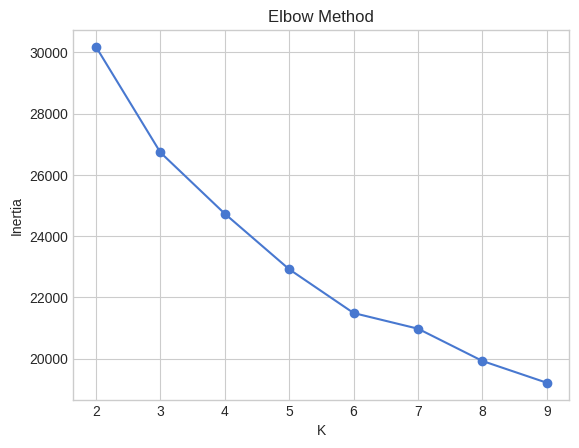

In [144]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [145]:
for k in [3,4,5,6]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f'cluster_{k}'] = kmeans.fit_predict(X_scaled)

In [146]:
df.groupby('cluster_3')['amount_balance_ratio'].mean()


cluster_3
0    0.089754
1    0.090320
2    0.503741
Name: amount_balance_ratio, dtype: float64

In [147]:
df.groupby('cluster_4')['amount_balance_ratio'].mean()


cluster_4
0    0.104918
1    0.502878
2    0.076148
3    0.090320
Name: amount_balance_ratio, dtype: float64

In [148]:
df.groupby('cluster_5')['amount_balance_ratio'].mean()

cluster_5
0    0.074419
1    0.505162
2    0.091166
3    0.100751
4    0.170386
Name: amount_balance_ratio, dtype: float64

In [149]:
df.groupby('cluster_6')['amount_balance_ratio'].mean()

cluster_6
0    0.087566
1    0.091305
2    0.057540
3    0.249428
4    0.149825
5    2.128858
Name: amount_balance_ratio, dtype: float64

## DBSCAN

In [153]:
eps_values = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
results = []
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_scaled)
    
    temp = df.copy()
    temp['cluster'] = labels
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    cluster_stats = temp.groupby('cluster')['amount_balance_ratio'].mean()
    
    results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'cluster_stats': cluster_stats
    })

In [154]:
for r in results:
    print(f"\n=== EPS = {r['eps']} ===")
    print(f"Clusters: {r['n_clusters']}, Noise: {r['n_noise']}")
    print(r['cluster_stats'])


=== EPS = 2.0 ===
Clusters: 22, Noise: 479
cluster
-1     0.522424
 0     0.043596
 1     0.278397
 2     0.360059
 3     0.065593
 4     0.046641
 5     0.332666
 6     0.080509
 7     0.070943
 8     0.061443
 9     0.038718
 10    0.078273
 11    0.066209
 12    0.041519
 13    0.219389
 14    0.087184
 15    0.081081
 16    0.017179
 17    0.076864
 18    0.235547
 19    0.030764
 20    0.067022
 21    0.080420
Name: amount_balance_ratio, dtype: float64

=== EPS = 2.5 ===
Clusters: 1, Noise: 183
cluster
-1    0.811826
 0    0.151369
Name: amount_balance_ratio, dtype: float64

=== EPS = 3.0 ===
Clusters: 1, Noise: 105
cluster
-1    1.033593
 0    0.163097
Name: amount_balance_ratio, dtype: float64

=== EPS = 3.5 ===
Clusters: 2, Noise: 34
cluster
-1    2.014476
 0    0.174925
 1    0.080174
Name: amount_balance_ratio, dtype: float64

=== EPS = 4.0 ===
Clusters: 1, Noise: 11
cluster
-1    3.462562
 0    0.185132
Name: amount_balance_ratio, dtype: float64

=== EPS = 5.0 ===
Clusters:

## GMM

In [155]:
components = range(2, 10)
bic_scores = []
aic_scores = []

for k in components:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

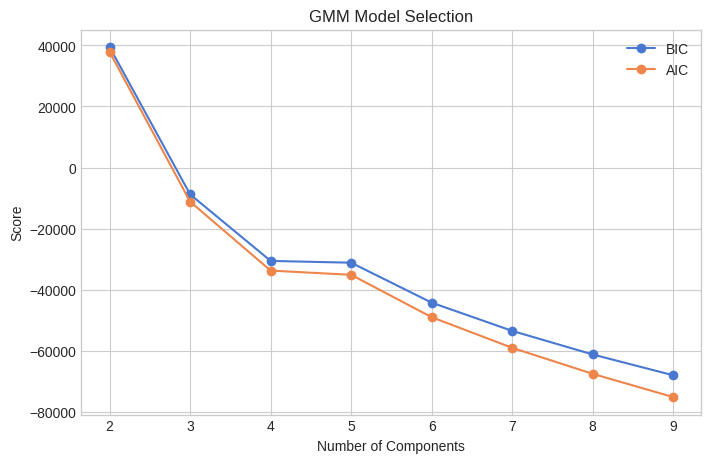

In [156]:
plt.figure(figsize=(8,5))
plt.plot(components, bic_scores, marker='o', label='BIC')
plt.plot(components, aic_scores, marker='o', label='AIC')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("GMM Model Selection")
plt.legend()
plt.show()

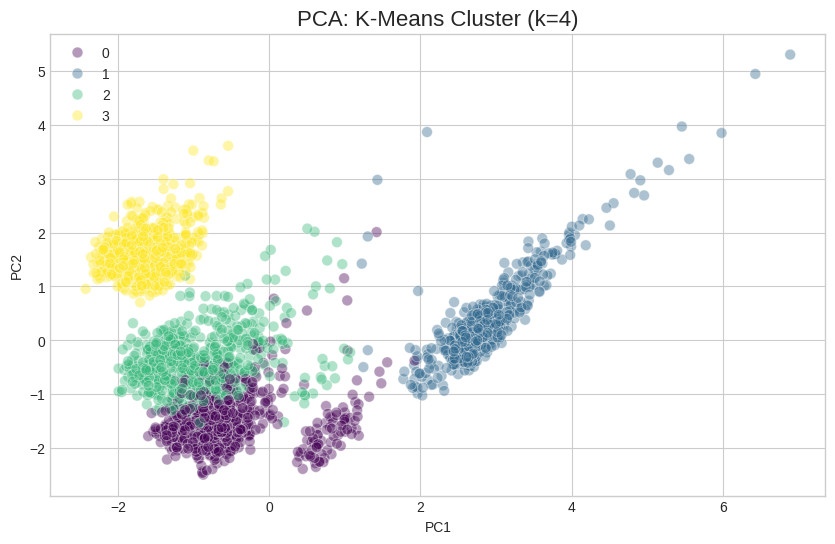

In [166]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['cluster_4']          
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=60,
    alpha=0.4
)


plt.title(f'PCA: K-Means Cluster (k=4)', fontsize=16)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### **Model Selection : Clustering Approach**

**Objective**
The goal is to identify a clustering method that provides meaningful behavioral segmentation while remaining interpretable for fraud risk analysis.

Three approaches were evaluated:

* K-Means
* Gaussian Mixture Model (GMM)
* DBSCAN

---

**K-Means (Elbow Method Analysis)**

The elbow curve shows a sharp decrease in inertia from K=2 to K=4, followed by diminishing improvements beyond that point.

Insight :
The most significant structural separation in the data is captured within the first four clusters.

Implication
Selecting more than four clusters adds complexity without delivering substantial gains in clustering quality.

---

**Gaussian Mixture Model (AIC/BIC Analysis)**

AIC and BIC continue decreasing until around K=7–8.

Insight :
Statistically, the data can be split into more components.

Implication
However, this results in over-segmentation, making clusters less interpretable and less useful for practical risk grouping.

---

**DBSCAN (Density-Based Clustering)**

Across different epsilon values:

* Small epsilon → too many clusters and excessive noise
* Large epsilon → collapse into a single cluster

Insight :
DBSCAN fails to produce stable and meaningful clusters.

Implication
The dataset does not exhibit clear density-based structure suitable for DBSCAN.

---

**K-Means (Final Selection)**

K-Means provides:

* Stable clustering results
* Clear separation in PCA visualization
* Consistent behavior across runs
* High interpretability

Insight :
The clustering structure aligns well with the data distribution, particularly under dimensionality reduction.

Implication
K-Means is the most practical method for translating patterns into risk segments.

---

**Final Choice: K = 4**

K = 4 is selected as the optimal number of clusters.

Insight :
Four clusters provide a clear and balanced segmentation of user behavior without over-fragmenting the data.

Implication
This aligns naturally with risk categorization:

* Low risk
* Medium risk
* High risk
* Extreme risk

---

**Key Takeaways**

* K-Means offers the best balance between performance and interpretability
* GMM overfits by introducing too many components
* DBSCAN is unstable for this dataset
* K = 4 provides a clean and actionable segmentation

---

**Modeling Implication**

Using K-Means with K = 4 enables:

* Clear behavioral grouping
* Straightforward mapping to risk tiers
* Practical implementation in fraud detection systems

This choice prioritizes interpretability and usability while maintaining strong clustering performance.


# Anomaly Detection

In [194]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,   # start here
    random_state=42
)

df['anomaly_score'] = -iso.fit(X_scaled).decision_function(X_scaled)
df['is_anomaly'] = iso.predict(X_scaled)  # -1 = anomaly
df['IsAnomaly']=df['is_anomaly']==1

## Anomaly Analysis

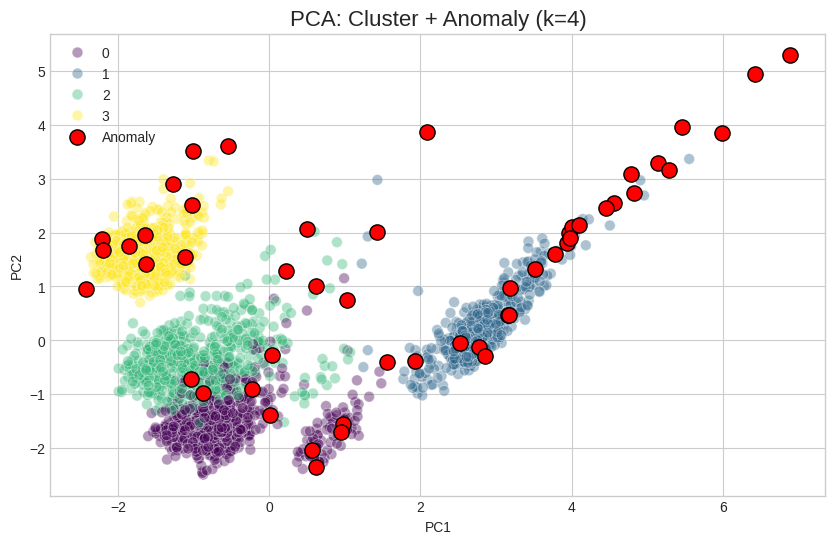

In [196]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['cluster_4']          # hasil KMeans kamu
pca_df['Anomaly'] = df['is_anomaly']         # hasil Isolation Forest

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=60,
    alpha=0.4
)
anomalies = pca_df['Anomaly'] == -1

plt.scatter(
    pca_df.loc[anomalies, 'PC1'],
    pca_df.loc[anomalies, 'PC2'],
    c='red',
    s=120,
    edgecolor='black',
    label='Anomaly'
)

plt.title(f'PCA: Cluster + Anomaly (k=4)', fontsize=16)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

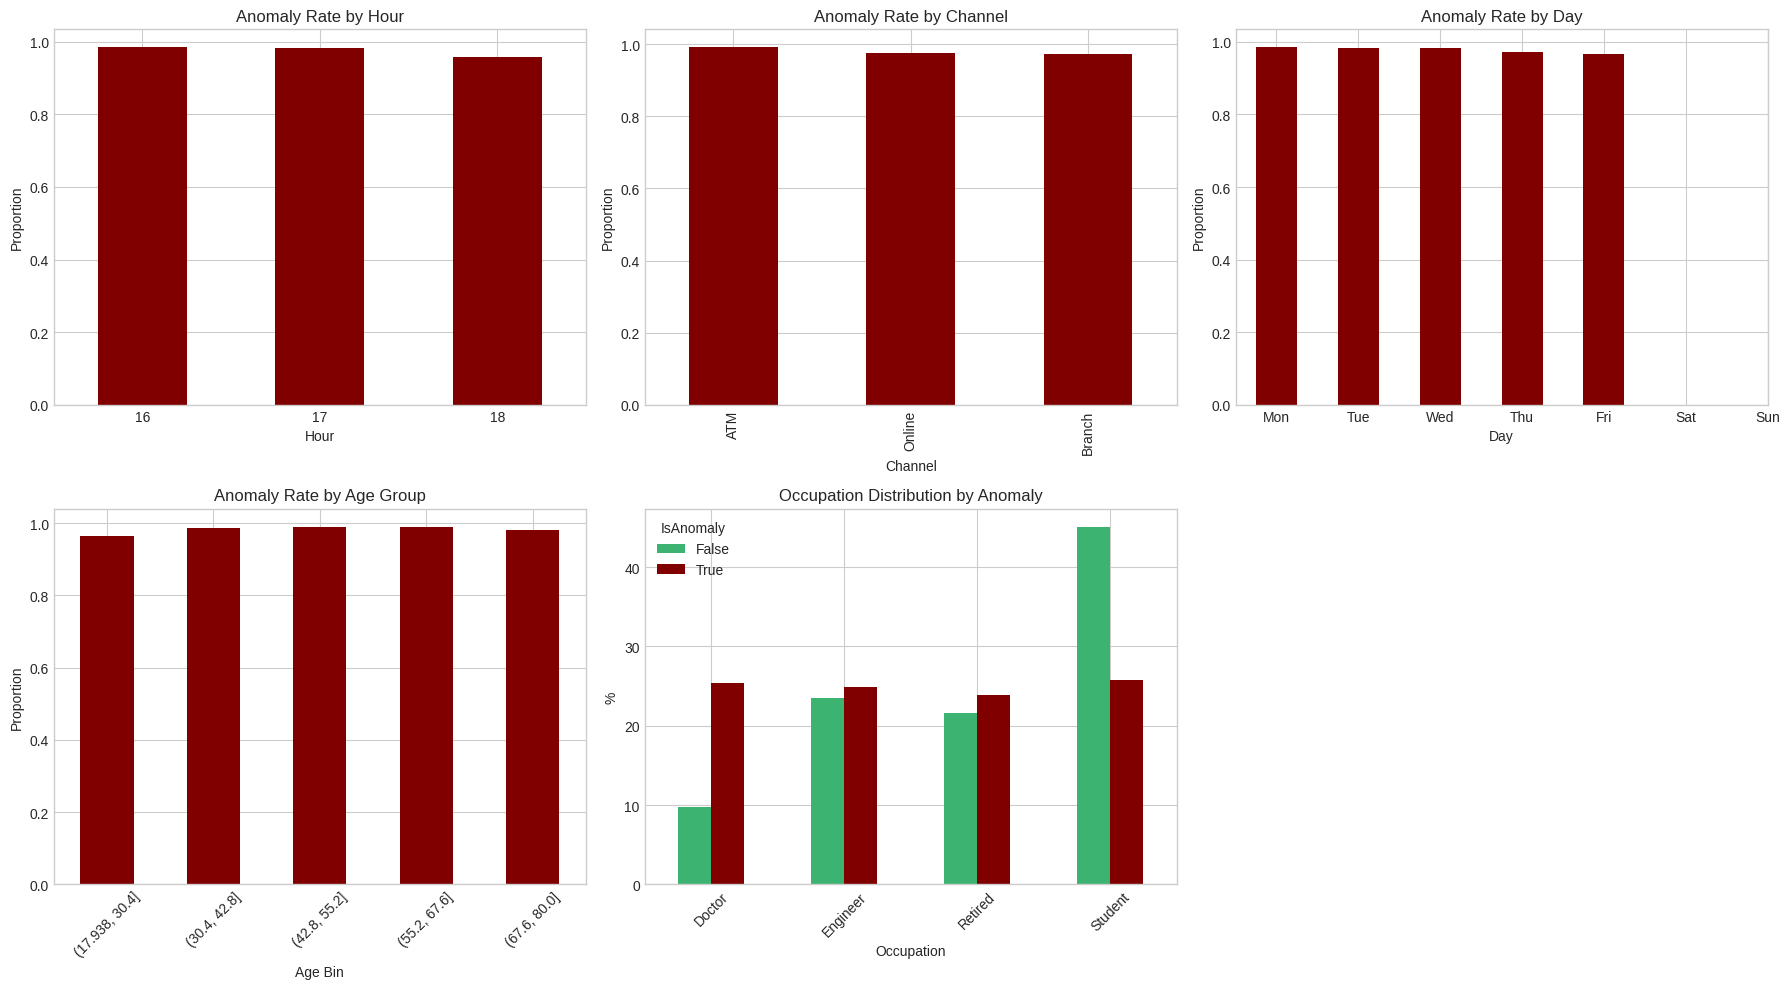

In [193]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
hourly = df.groupby('Hour')['IsAnomaly'].value_counts(normalize=True).unstack().fillna(0)
hourly[True].plot(kind='bar', color='maroon', ax=axes[0,0])

axes[0,0].set_title('Anomaly Rate by Hour')
axes[0,0].set_ylabel('Proportion')
axes[0,0].set_xlabel('Hour')
axes[0,0].tick_params(axis='x', rotation=0)
fraud_rate_by_channel = df.groupby('Channel')['IsAnomaly'].mean().sort_values(ascending=False)
fraud_rate_by_channel.plot(kind='bar', color='maroon', ax=axes[0,1])
axes[0,1].set_title('Anomaly Rate by Channel')
axes[0,1].set_ylabel('Proportion')
axes[0,1].set_xlabel('Channel')
dow = df.groupby('DayOfWeek')['IsAnomaly'].value_counts(normalize=True).unstack().fillna(0)
dow[True].plot(kind='bar', color='maroon', ax=axes[0,2])

axes[0,2].set_title('Anomaly Rate by Day')
axes[0,2].set_ylabel('Proportion')
axes[0,2].set_xlabel('Day')
axes[0,2].set_xticks(range(7))
axes[0,2].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
age_bins = pd.cut(df['CustomerAge'], bins=5)
age_anomaly = df.groupby(age_bins)['IsAnomaly'].mean()
age_anomaly.plot(kind='bar', color='maroon', ax=axes[1,0])
axes[1,0].set_title("Anomaly Rate by Age Group")
axes[1,0].set_ylabel("Proportion")
axes[1,0].set_xlabel("Age Bin")
axes[1,0].tick_params(axis='x', rotation=45)
occupation_anomaly_dist = pd.crosstab(df['CustomerOccupation'], df['IsAnomaly'])
occupation_anomaly_percent = occupation_anomaly_dist.div(occupation_anomaly_dist.sum(axis=0), axis=1) * 100

occupation_anomaly_percent.plot(
    kind='bar',
    color=['mediumseagreen', 'maroon'],
    ax=axes[1,1]
)

axes[1,1].set_title('Occupation Distribution by Anomaly')
axes[1,1].set_ylabel('%')
axes[1,1].set_xlabel('Occupation')
axes[1,1].tick_params(axis='x', rotation=45)
fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

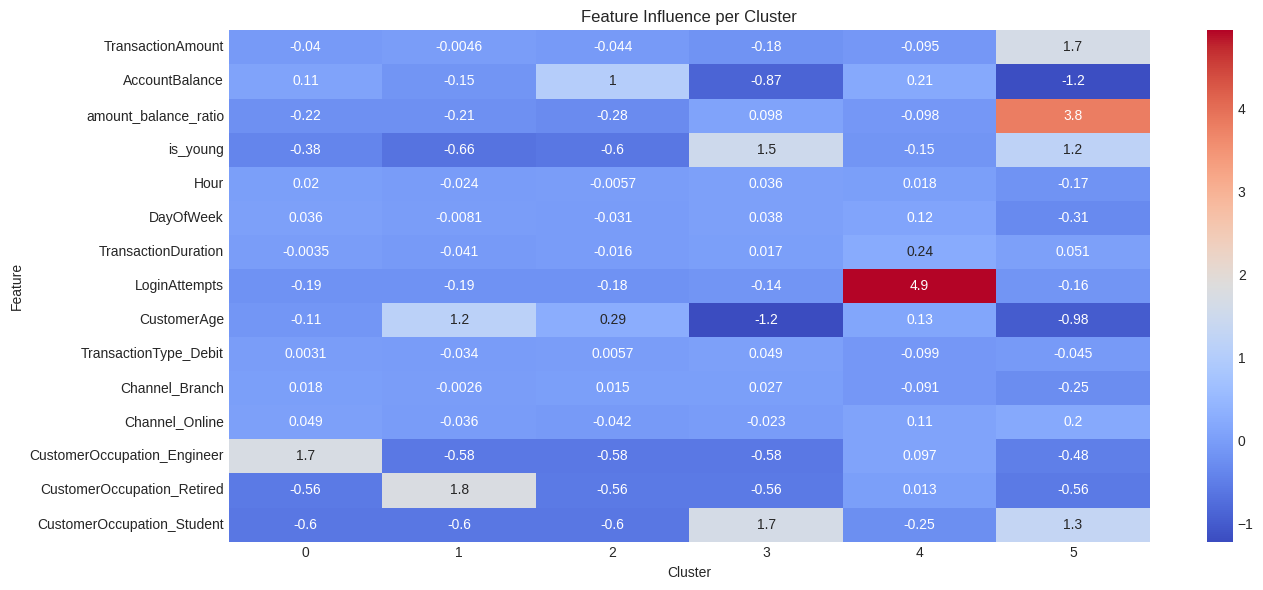

In [192]:
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
cluster_centers['Cluster'] = cluster_centers.index
cluster_centers = cluster_centers.set_index('Cluster')
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_centers.T, cmap='coolwarm', annot=True)
plt.title("Feature Influence per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### **EDA: Anomaly Analysis**

**Objective**
This analysis evaluates whether temporal, channel, and demographic features contribute to anomaly detection, and how they compare against behavioral signals.

---
**Clustering Analysis (K-Means, K = 4)**

PCA visualization of clustering results reveals four distinct behavioral segments:

* A dense cluster on the right forming a curved structure
* Multiple compact clusters on the left representing different user behaviors
* Clear separation between high-value trajectory patterns and normal clusters

Insight :
The right-side curved cluster represents transactions with progressively increasing behavioral intensity (e.g., higher ratios or extreme values).

Implication
Clustering successfully captures underlying behavioral patterns that are not visible through individual features alone.

---

**Anomaly Distribution in Feature Space**

Anomalies (highlighted in red) are distributed across:

* Extreme regions of the curve (high PC1 values)
* Boundary areas between clusters
* Occasional points within dense clusters

Insight :
Anomalies are not limited to global extremes but also occur as **contextual outliers within clusters**.

Implication
This confirms that anomaly detection is capturing both:

* Global anomalies (extreme behavior)
* Local anomalies (unexpected behavior within a segment)

---

**Time-Based Features (Hour & Day of Week)**

The anomaly rate across hours (16–18) and weekdays shows minimal variation.

Insight :
Anomaly proportions remain consistently high across all observed time intervals.

Implication
Time-based features provide limited discriminatory power in this dataset, primarily due to the narrow time window of transactions.

---

**Channel Analysis**

Anomaly rates across transaction channels (ATM, Online, Branch) are nearly identical.

Insight :
There is no meaningful difference in anomaly distribution across channels.

Implication
Channel does not appear to be a strong standalone predictor of anomalous behavior in this dataset.

---

**Age-Based Analysis**

Customer age was grouped into bins, and anomaly rates were evaluated across these segments.

Insight :
Anomaly rates remain relatively uniform across all age groups.

Implication
Age does not directly drive anomaly classification and acts as a secondary or indirect signal rather than a primary risk factor.

---

**Occupation Analysis**

The distribution of occupations differs slightly between normal and anomalous transactions.

Insight :
Certain occupations (e.g., students) appear more frequently in the dataset, but differences between normal and anomaly distributions are not substantial.

Implication
Observed variation is likely influenced by data composition rather than a true causal relationship, indicating potential confounding effects.

---


**Key Takeaways**

* Temporal features (hour, day) show **no significant impact**
* Channel and demographic features provide **limited or weak signals**
* Behavioral structure is better captured through clustering
* Anomalies are **context-dependent**, not purely magnitude-based

---

**Final Interpretation**

The analysis highlights a critical principle:

> Anomaly detection in this dataset is driven primarily by **behavioral patterns**, rather than time, channel, or demographic attributes.

Clustering reveals meaningful segmentation, while traditional features contribute only marginally.

---

# Risk Mapping

In [212]:
df.groupby('cluster_4')['amount_balance_ratio'].mean()


cluster_4
0    0.104918
1    0.502878
2    0.076148
3    0.090320
Name: amount_balance_ratio, dtype: float64

In [213]:
cluster_risk = df.groupby('cluster_4')['amount_balance_ratio'].mean()

cluster_rank = cluster_risk.sort_values(ascending=False)

rank_map = {cluster: rank for rank, cluster in enumerate(cluster_rank.index)}

df['cluster_rank'] = df['cluster_4'].map(rank_map)

In [214]:
cluster_risk

cluster_4
0    0.104918
1    0.502878
2    0.076148
3    0.090320
Name: amount_balance_ratio, dtype: float64

In [215]:
cluster_rank 

cluster_4
1    0.502878
0    0.104918
3    0.090320
2    0.076148
Name: amount_balance_ratio, dtype: float64

In [216]:
rank_map

{1: 0, 0: 1, 3: 2, 2: 3}

In [218]:
def risk_label(rank):
    if rank == 0:
        return 'Very High'
    elif rank == 1:
        return 'High'
    elif rank == 2:
        return 'Medium'
    else:
        return 'low'

df['risk_kmeans'] = df['cluster_rank'].apply(risk_label)

In [220]:
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,cluster_3,cluster_4,cluster_5,cluster_6,anomaly_score,is_anomaly,isAnomaly,IsAnomaly,cluster_rank,risk_kmeans
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,...,0,2,0,2,-0.149545,1,True,True,3,low
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,...,0,2,0,2,-0.123288,1,True,True,3,low
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,...,2,1,1,3,-0.068005,1,True,True,0,Very High
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,...,2,1,1,3,-0.042009,1,True,True,0,Very High
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,...,2,1,1,3,-0.021453,1,True,True,0,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,...,0,2,0,2,-0.049485,1,True,True,3,low
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,...,0,2,0,2,-0.081737,1,True,True,3,low
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,...,1,3,2,1,-0.117973,1,True,True,2,Medium
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,...,2,1,1,3,-0.073858,1,True,True,0,Very High


# Risk Trade-off

In [223]:
total_amount = df['TransactionAmount'].sum()

df_exposure = df.groupby('risk_kmeans')['TransactionAmount'].sum() / total_amount
df_exposure = df_exposure.sort_values(ascending=False)
df_exposure

risk_kmeans
Very High    0.280399
low          0.241943
High         0.241654
Medium       0.236003
Name: TransactionAmount, dtype: float64

In [224]:
extreme = df[df['risk_kmeans'] == 'Very High']

extreme_users = len(extreme) / len(df)
extreme_amount = extreme['TransactionAmount'].sum() / total_amount

extreme_users, extreme_amount

(0.2643312101910828, np.float64(0.2803990210386634))

In [234]:
# Very High
extreme = df[df['risk_kmeans'] == 'Very High']
extreme_users = len(extreme) / len(df)
extreme_amount = extreme['TransactionAmount'].sum() / total_amount

# High 
high = df[df['risk_kmeans'].isin(['High'])]
high_users = len(high) / len(df)
high_amount = high['TransactionAmount'].sum() / total_amount

#Medium
med = df[df['risk_kmeans'].isin(['Medium'])]
med_users = len(med) / len(df)
med_amount = med['TransactionAmount'].sum() / total_amount

# Medium
low = df[df['risk_kmeans'] == 'low']
low_users = len(low) / len(df)
low_amount = low['TransactionAmount'].sum() / total_amount

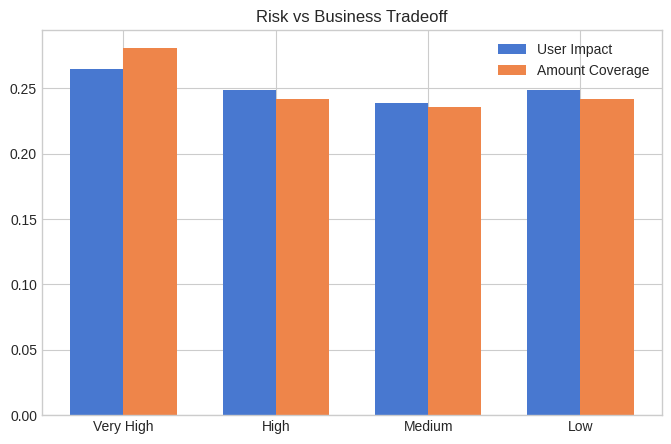

In [235]:

labels = ['Very High', 'High','Medium', 'Low']
users = [extreme_users, high_users,med_users, low_users]
amounts = [extreme_amount, high_amount, med_amount,low_amount]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, users, width, label='User Impact')
plt.bar(x + width/2, amounts, width, label='Amount Coverage')

plt.xticks(x, labels)
plt.title("Risk vs Business Tradeoff")
plt.legend()
plt.show()

### **Risk vs Business Tradeoff Analyst**

**Objective**
This analysis evaluates the tradeoff between fraud risk segmentation and business impact by comparing:

* **User Impact** (proportion of users affected)
* **Amount Coverage** (proportion of transaction value covered)

across different risk levels.

---

**Risk Segmentation Overview**

Transactions are grouped into four risk tiers:

* Very High
* High
* Medium
* Low

Each segment represents a different level of behavioral risk derived from clustering and anomaly detection.

---

**User Impact vs Amount Coverage**

Insight :
The distribution of users and transaction amounts is relatively balanced across risk segments, with slight variations:

* **Very High risk** captures a slightly higher proportion of transaction value compared to user count
* **Low risk** has a slightly higher user proportion but lower relative transaction value
* **High and Medium risk** segments are relatively balanced between user impact and amount coverage

---

**Interpretation**

Insight :
Higher-risk segments tend to concentrate more transaction value per user, while lower-risk segments include more users with relatively smaller transaction amounts.

Implication
Targeting higher-risk segments can yield greater financial coverage while affecting a smaller portion of users.

---

**Tradeoff Analysis**

* Focusing on **Very High risk**:

  * Maximizes financial protection
  * Minimizes user disruption
  * Most efficient for strict fraud controls

* Including **High risk**:

  * Increases coverage
  * Slightly increases user impact
  * Balanced approach

* Expanding to **Medium and Low risk**:

  * Marginal gain in coverage
  * Significant increase in affected users
  * Lower efficiency

---

**Key Takeaways**

* Risk segmentation enables **targeted intervention strategies**
* The **Very High risk group provides the best risk-to-impact ratio**
* Expanding coverage beyond high-risk segments leads to **diminishing returns**
* Effective fraud prevention requires balancing **coverage vs user experience**

---

**Final Interpretation**

This analysis highlights a key principle:

> Not all transactions should be treated equally—risk-based segmentation allows for **prioritized intervention**, maximizing financial protection while minimizing unnecessary user friction.

---

# Efficiency

In [239]:
df['cluster_score'] = 3 - df['cluster_rank']

df['risk_score'] = (
    0.5 * df['amount_balance_ratio'] +
    0.3 * df['cluster_score']
)

In [241]:
df_sorted = df.sort_values(by='risk_score', ascending=False).reset_index(drop=True)

In [242]:
df_sorted['cum_users'] = (df_sorted.index + 1) / len(df_sorted)
df_sorted['cum_amount'] = df_sorted['TransactionAmount'].cumsum() / df['TransactionAmount'].sum()

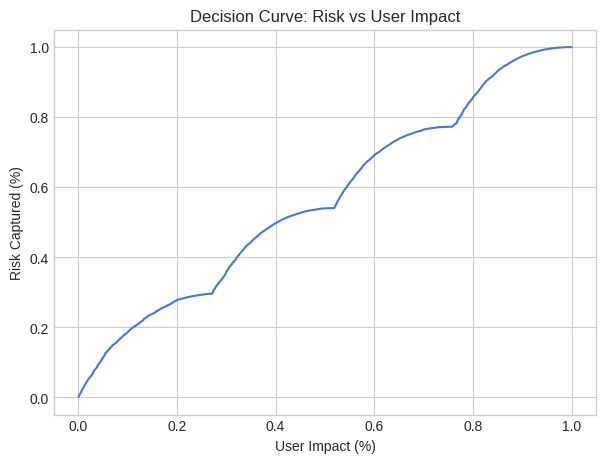

In [243]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(df_sorted['cum_users'], df_sorted['cum_amount'])

plt.xlabel("User Impact (%)")
plt.ylabel("Risk Captured (%)")
plt.title("Decision Curve: Risk vs User Impact")

plt.grid(True)
plt.show()

In [244]:
target = 0.2  # 20% users

optimal_point = df_sorted[df_sorted['cum_users'] >= target].iloc[0]

optimal_point[['cum_users', 'cum_amount']]

cum_users     0.200239
cum_amount    0.278323
Name: 502, dtype: object

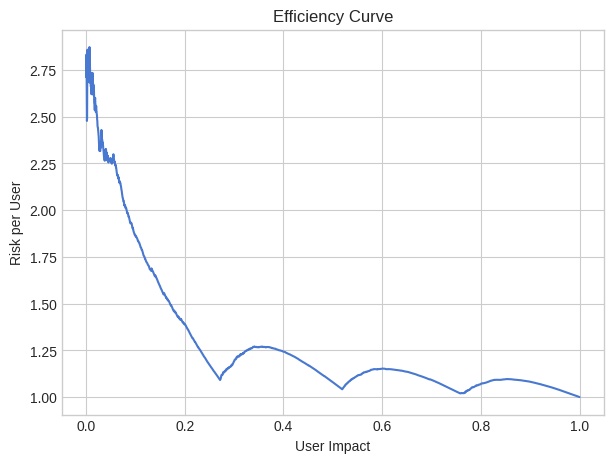

In [245]:
df_sorted['efficiency'] = df_sorted['cum_amount'] / df_sorted['cum_users']

plt.figure(figsize=(7,5))
plt.plot(df_sorted['cum_users'], df_sorted['efficiency'])
plt.title("Efficiency Curve")
plt.xlabel("User Impact")
plt.ylabel("Risk per User")
plt.show()

**EDA: Efficiency Curve – Risk per User (Fraud Strategy Perspective)**

**Objective**
This analysis evaluates how efficiently risk is captured as more users are targeted, measured by:

> **Risk per User = Risk Captured / User Impact**

The goal is to assess the **quality of targeting**, not just total coverage.

---

**Curve Interpretation**

* **X-axis (User Impact):** proportion of users targeted
* **Y-axis (Risk per User):** average risk captured per targeted user

---

**Key Observations**

* The curve starts at a **very high value (~2.8–2.9)**
* Rapid decline in efficiency as user coverage increases
* Gradual flattening toward ~1.0 at full coverage

Insight
The highest-risk users contribute **disproportionately large amounts of risk**, making early targeting extremely efficient.

---

**Efficiency Dynamics**

* Top ~5–10% users:

  * Extremely high risk per user
  * Strong concentration of anomalous behavior

* Around ~20–30% users:

  * Efficiency drops significantly
  * Still above baseline (>1.0), meaning useful targeting

* Beyond ~50% users:

  * Efficiency stabilizes near ~1.0
  * Additional users contribute **average-level risk only**

---

**Diminishing Returns**

Insight
As more users are included:

* The marginal risk captured per user decreases
* The system begins targeting **normal or low-risk users**

Implication
Expanding intervention beyond high-risk segments leads to **reduced efficiency and unnecessary user impact**.

---

**Optimal Targeting Zone**

The most efficient region lies within:

* **Top ~10–30% of users**

In this range:

* Risk per user is significantly above average
* Intervention yields strong returns

---

**Strategic Interpretation**

This curve confirms:

> Effective fraud detection is not about covering everyone, but about **prioritizing high-risk users**.

---

**Key Takeaways**

* Risk is highly concentrated in a small subset of users
* Early targeting provides **maximum efficiency**
* Efficiency declines rapidly as coverage expands
* Beyond a certain point, targeting becomes **indistinguishable from random selection**

---

**Final Interpretation**

The efficiency curve demonstrates that:

> A well-calibrated risk scoring system allows organizations to **maximize impact per action**, ensuring that each intervention targets users with the highest expected risk.


# Profit VS Loss Analysis


**EDA: Profit Curve & Cost–Benefit Analysis**

**Objective**
Identify the optimal threshold that **maximizes net business value** by balancing fraud loss prevention and intervention cost.

---

**Key Framework**

* **Loss Prevented** = Fraud amount captured
* **Cost** = Cost per user × users impacted
* **Profit** = Loss Prevented − Cost

---

**Approach**

* Rank users by **risk_score**
* Simulate thresholds (**top X% users**)
* Measure:

  * **Risk captured**
  * **User impact**
  * **Cost**
  * **Net profit**

---

**Key Insight**

* **High-risk users contribute disproportionately to total value**
* Profit increases **rapidly at early thresholds**
* **Marginal gains decline** as more users are included

---

**Decision Principle**

Focus on the threshold where:

→ **Profit is high**
→ **Efficiency remains strong**
→ **User impact is controlled**


In [246]:
df_sorted = df.sort_values('risk_score', ascending=False).reset_index(drop=True)
df_sorted['cum_users'] = (df_sorted.index + 1) / len(df_sorted)
df_sorted['cum_amount'] = df_sorted['TransactionAmount'].cumsum() / df_sorted['TransactionAmount'].sum()
df_sorted['fraud_amount'] = df_sorted['TransactionAmount'] * df_sorted['IsAnomaly']
df_sorted['cum_fraud'] = df_sorted['fraud_amount'].cumsum()
cost_per_user = 2  
df_sorted['cost'] = (df_sorted.index + 1) * cost_per_user
df_sorted['profit'] = df_sorted['cum_fraud'] - df_sorted['cost']

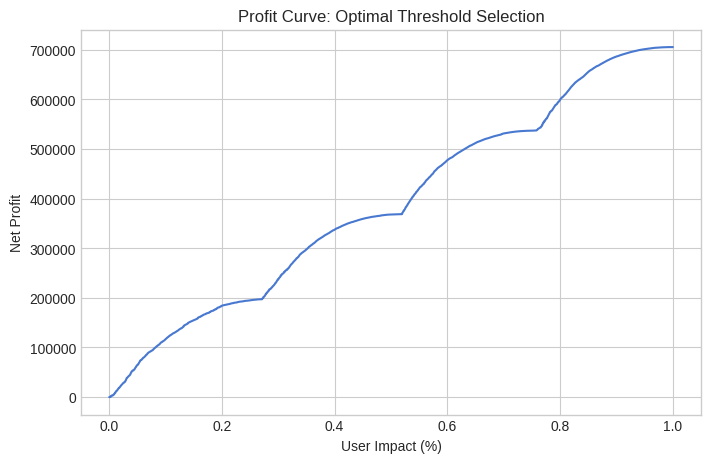

In [247]:
plt.figure(figsize=(8,5))
plt.plot(df_sorted['cum_users'], df_sorted['profit'])
plt.xlabel("User Impact (%)")
plt.ylabel("Net Profit")
plt.title("Profit Curve: Optimal Threshold Selection")
plt.show()

**EDA: Profit Curve – Optimal Threshold Selection (Fraud Strategy Perspective)**

**Objective**
This analysis evaluates the net business value of the fraud detection strategy by balancing:

* **Loss prevented** (captured fraud amount)
* **Intervention cost** (cost of acting on users)

The goal is to identify the **optimal threshold** that maximizes net profit.

---

**Curve Interpretation**

* **X-axis (User Impact):** proportion of users targeted
* **Y-axis (Net Profit):** cumulative profit = fraud prevented − intervention cost

---

**Key Observations**

* Net profit increases steadily as more users are included
* The curve shows strong gains in early segments, followed by slower growth
* No sharp decline is observed within the range

Insight
High-risk users contribute significantly to profit, and expanding coverage continues to add value—though at a decreasing rate.

---

**Marginal Behavior**

* Early region (0–30% users):

  * Rapid profit increase
  * High-value targets dominate

* Mid region (30–70% users):

  * Profit continues to grow
  * Marginal gains begin to slow

* Late region (70–100% users):

  * Growth flattens
  * Additional users contribute limited incremental profit

---

**Optimal Threshold Consideration**

Unlike a typical curve with a clear peak, this curve:

* Continues increasing toward full coverage
* Suggests that **intervention cost is relatively low compared to fraud loss**

Insight
The absence of a peak indicates that the current cost assumption may be **too small**, or fraud impact is **very high across users**.

---

**Strategic Interpretation**

This result implies:

> From a purely financial perspective, expanding coverage broadly remains profitable under current assumptions.

However:

* This ignores **real-world constraints**:

  * User friction
  * Operational limits
  * False positives

---

**Adjusted Decision Insight**

Even though profit increases:

* Efficiency (from previous analysis) declines
* User experience cost is not fully captured

Implication
The optimal strategy should not be based solely on maximum profit, but on:

* **Efficiency (risk per user)**
* **User impact tolerance**

---

**Key Takeaways**

* Profit is strongly driven by early high-risk segments
* Marginal gains decrease as coverage expands
* No natural cutoff suggests **cost assumptions need calibration**
* Pure profit maximization may lead to **over-intervention**

---

**Final Interpretation**

The profit curve demonstrates that:

> While broad intervention can maximize financial recovery, the optimal decision must balance **profit, efficiency, and user experience**, rather than relying on a single metric.

---

# Next Step

**Next Step**

* Introduce more realistic cost modeling:
* Separate **false positive cost vs true fraud savings**
* Combine:
  * Profit curve
  * Efficiency curve
  * Decision curve